In [1]:
import kagglehub
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
print(path)

100%|██████████| 393k/393k [00:00<00:00, 684kB/s]

Extracting files...
/home/jonatas-locateli/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1


In [2]:
import os

for f in os.listdir(path):
    print(f)

bank-additional-full.csv
bank-additional-names.txt


In [3]:
import pandas as pd
import os

csv_path = os.path.join(path, "bank-additional-full.csv")
df = pd.read_csv(csv_path, sep=";")

df.shape


(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [8]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} ({pct:.2f}%)")

job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


In [9]:
df.groupby('default')['y'].value_counts(normalize=True).unstack()

y,no,yes
default,,
no,0.87121,0.12879
unknown,0.94847,0.05153
yes,1.00000,NaN


In [10]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [11]:
(df['pdays'] == 999).sum()
(df['pdays'] == 999).mean() * 100

np.float64(96.32174419733903)

In [12]:
df['contatado_antes'] = (df['pdays'] != 999).astype(int)

In [13]:
df['contatado_antes'].value_counts()

contatado_antes
0    39673
1     1515
Name: count, dtype: int64

In [14]:
df.groupby('y')['duration'].mean()

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

In [15]:
df = df.drop(columns=['duration', 'pdays'])

In [17]:
df.shape

(41188, 20)

In [18]:
import matplotlib.pyplot as plt

df.groupby('y')['age'].mean()

y
no     39.911185
yes    40.913147
Name: age, dtype: float64

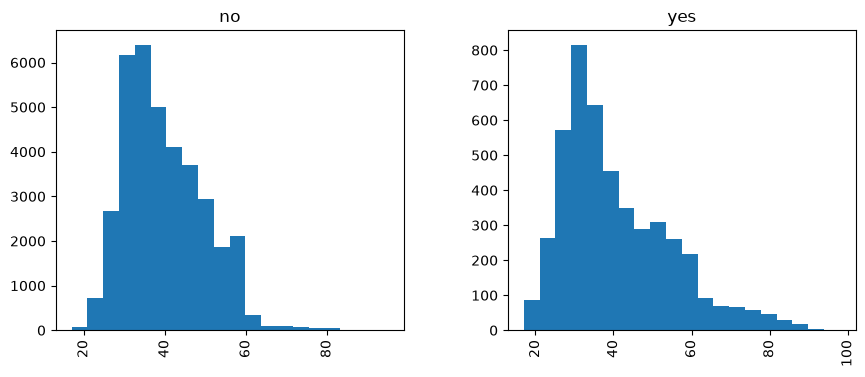

In [19]:
df['age'].hist(by=df['y'], bins=20, figsize=(10,4))
plt.show()

In [20]:
df['faixa_etaria'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100])
df.groupby('faixa_etaria')['y'].value_counts(normalize=True).unstack()

/tmp/ipykernel_18436/2900949073.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_etaria')['y'].value_counts(normalize=True).unstack()


y,no,yes
faixa_etaria,,
"(0, 25]",0.790516,0.209484
"(25, 35]",0.882805,0.117195
"(35, 45]",0.914902,0.085098
"(45, 55]",0.913080,0.086920
"(55, 65]",0.847789,0.152211
"(65, 100]",0.531502,0.468498
